In [21]:
import pandas as pd
%matplotlib inline
import numpy as np
import torch
import random
from d2l import torch  as d2l
import os
import pandas

In [23]:
#Define the basic function
def  synthetic_data(w,b,num_examples):
    x =torch.normal(0,1,(num_examples,len(w))) # x is a random whose average value is 0 and variance is 1
    y = torch.matmul(x,w) + b
    y += torch.normal(0,0.01,y.shape)
    return x, y.reshape((-1,1))

In [20]:
# input the real data
true_w = torch.tensor([2,-3.4])
true_b =4.2
features,labels = synthetic_data(true_w,true_b,100)
# python implements encapsulation by setting functions

In [21]:
print('features',features[0],'\nlabel:',labels[0])

features tensor([-0.5461, -1.3235]) 
label: tensor([7.6076])


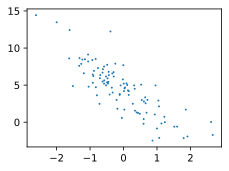

In [39]:
# diagraming (not neccessary)
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1);
#.detach().numpy() convert tensor in torch into numpy arrays

In [9]:
# implemetation of reading data in small batches
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    # shuffle the batch

    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)]) # be careful of the order!
        yield features[batch_indices],labels[batch_indices] # python use byval

    #acquires the shuffled array but read in order



In [10]:
batch_size =10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.2378,  1.3720],
        [-0.5164, -0.4977],
        [ 1.3826,  0.5226],
        [ 1.2200,  1.5439],
        [-0.1055,  2.0543],
        [ 0.7198, -0.5189],
        [ 0.4786,  1.3309],
        [ 1.8755,  1.5474],
        [ 1.2837, -0.3837],
        [ 0.8870,  0.2218]]) 
 tensor([[ 0.0362],
        [ 4.8556],
        [ 5.1826],
        [ 1.3888],
        [-2.9835],
        [ 7.4118],
        [ 0.6318],
        [ 2.6890],
        [ 8.0622],
        [ 5.2103]])


In [11]:
#define the initialization model
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad=True)

In [12]:
def linreg(x,w,b):
    return torch.matmul(x,w) + b

In [13]:
# define the loss funcion
# here we use the MSE
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape) **2 /2)

In [14]:
# Define the optimization algorithom
def sgd(params,lr,batch_size):# sgd optimizer
    with torch.no_grad(): # exit the grad.mode
        for param in params: # Context Manager
            param -= lr*param.grad / batch_size # grad. Normalize gradient by batch_size
            param.grad.zero_()  # Remember to clear the gradient each time


In [15]:
#Training
lr = 0.3
num_epochs =3 # Generate the batch
net = linreg
loss = squared_loss

# two nested for loop is typically used in training body
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y) # calcluate loss function
        l.sum().backward()
        sgd([w,b],lr,batch_size) # the unpackaging feature of python
    with torch.no_grad():
        train_l =loss (net(features,w,b),labels)
        print(f'epoch {epoch+1}: train_l {train_l}')

epoch 1: train_l tensor([[-35.4849],
        [-21.0357],
        [-21.6680],
        [ -3.2254],
        [-30.5374],
        [-35.6358],
        [ -8.3631],
        [-50.3602],
        [ -7.8979],
        [-17.1683],
        [-13.2282],
        [-28.2386],
        [ -2.9242],
        [-42.1938],
        [-10.1371],
        [-14.6434],
        [ -4.1356],
        [-46.0582],
        [-21.1743],
        [ -9.4454],
        [-15.3005],
        [ -3.6396],
        [-40.9864],
        [-20.0603],
        [-12.4276],
        [ -3.0575],
        [-12.5368],
        [-13.2958],
        [ -7.7887],
        [-47.5506],
        [-33.6938],
        [-17.7645],
        [-13.6604],
        [-14.7192],
        [ -2.9216],
        [ -3.4329],
        [ -6.0344],
        [-10.2294],
        [ -5.0978],
        [ -3.2827],
        [-29.4628],
        [-17.7362],
        [-15.2152],
        [-24.0136],
        [ -6.8605],
        [ -5.8002],
        [ -6.4844],
        [-41.8536],
        [-49.4477],
   

In [ ]:
#Comparison between parameters
print(f'w的误差：{true_w -w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b-b}')